<a href="https://colab.research.google.com/github/setdaygamer12/NguyenDucMinh-baitap-AI/blob/B%C3%A0i-t%E1%BA%ADp-AI/baitapAI-tu%E1%BA%A7n-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 33.6 MB/s eta 0:00:00


In [ ]:
a=input('nhap:')
if a in ['xau','xấu']:
  a=15
elif a in ['trung binh','medium']:
  a=50
elif a in ['tot','tốt']:
  a=90
print(a)

nhap:xau
15


Ride_distance (0->50): 15
Traffic_condition (0->100): 80
Demand_level (0->100): 80
Weather condition (dep(0->30), trung binh(20->80), xau(60->100)): 50
Rating (1->5): 4
Ride_punctuality (on time(40->80), late (0->50), early(70->100)): 50
 Price (Giá cước): 148.99 nghìn đồng
 Point (Điểm thưởng): 691.10 điểm


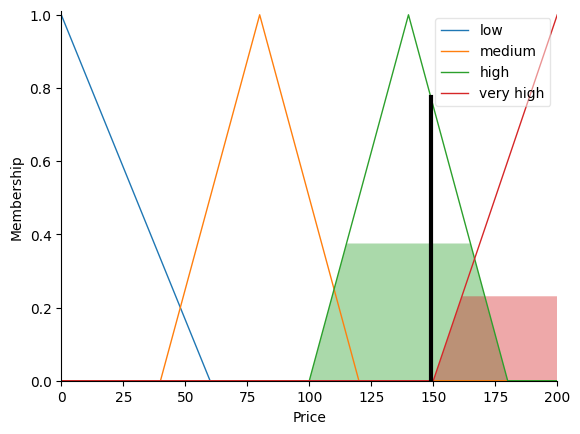

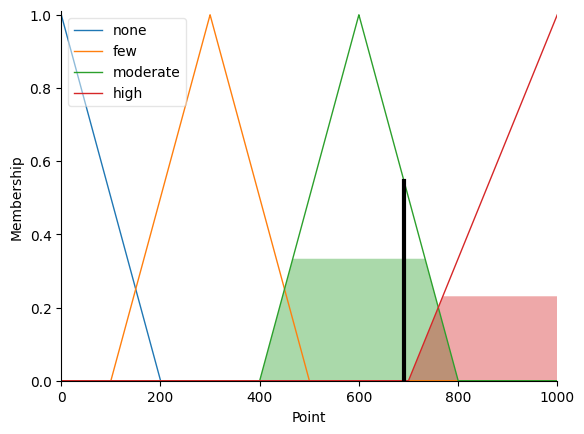

In [ ]:
import numpy as np #2.11 another version
import skfuzzy as fuzz
from skfuzzy import control as ctrl
Ride_distance = ctrl.Antecedent(np.arange(0, 50.1, 0.1), 'Ride_distance')
Traffic_condition = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Traffic_condition')
Demand_level = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Demand_level')
Weather_condition = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Weather_condition')
Rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Rating')
Ride_punctuality = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Ride_punctuality')
Price = ctrl.Consequent(np.arange(0, 200.1, 0.1), 'Price')
Point = ctrl.Consequent(np.arange(0, 1000.1, 0.1), "Point")

Ride_distance['short'] = fuzz.trimf(Ride_distance.universe, [0, 0, 5])
Ride_distance['medium'] = fuzz.trimf(Ride_distance.universe, [2, 10, 18])
Ride_distance['long'] = fuzz.trimf(Ride_distance.universe, [12, 25, 35])
Ride_distance['very long'] = fuzz.trimf(Ride_distance.universe, [25, 50, 50])

Traffic_condition['low'] = fuzz.trimf(Traffic_condition.universe, [0, 0, 30])
Traffic_condition['medium'] = fuzz.trimf(Traffic_condition.universe, [20, 45, 70])
Traffic_condition['high'] = fuzz.trimf(Traffic_condition.universe, [60, 100, 100])

Demand_level['low'] = fuzz.trimf(Demand_level.universe, [0, 0, 30])
Demand_level['medium'] = fuzz.trimf(Demand_level.universe, [20, 45, 70])
Demand_level['high'] = fuzz.trimf(Demand_level.universe, [60, 100, 100])

Weather_condition['good'] = fuzz.trimf(Weather_condition.universe, [0, 0, 30])
Weather_condition['medium'] = fuzz.trimf(Weather_condition.universe, [20, 45, 70])
Weather_condition['bad'] = fuzz.trimf(Weather_condition.universe, [60, 100, 100])

Rating['poor'] = fuzz.trimf(Rating.universe, [0, 0, 2.5])
Rating['average'] = fuzz.trimf(Rating.universe, [1.5, 3, 4.5])
Rating['good'] = fuzz.trimf(Rating.universe, [3.5, 5, 5])

Ride_punctuality['late'] = fuzz.trimf(Ride_punctuality.universe, [0, 0, 50])
Ride_punctuality['on time'] = fuzz.trimf(Ride_punctuality.universe, [40, 60, 80])
Ride_punctuality['early'] = fuzz.trimf(Ride_punctuality.universe, [70, 100, 100])

Price['low'] = fuzz.trimf(Price.universe, [0, 0, 60])
Price['medium'] = fuzz.trimf(Price.universe, [40, 80, 120])
Price['high'] = fuzz.trimf(Price.universe, [100, 140, 180])
Price['very high'] = fuzz.trimf(Price.universe, [150, 200, 200])

Point['none'] = fuzz.trimf(Point.universe, [0, 0, 200])
Point['few'] = fuzz.trimf(Point.universe, [100, 300, 500])
Point['moderate'] = fuzz.trimf(Point.universe, [400, 600, 800])
Point['high'] = fuzz.trimf(Point.universe, [700, 1000, 1000])

r1 = ctrl.Rule(Ride_distance['short'] & Traffic_condition['low'] & Demand_level['low'], Price['low'])
r2 = ctrl.Rule(Ride_distance['short'] & Traffic_condition['medium'] & Demand_level['high'], Price['medium'])
r3 = ctrl.Rule(Ride_distance['medium'] & Traffic_condition['high'] & Demand_level['high'], Price['high'])
r4 = ctrl.Rule(Ride_distance['long'] & Traffic_condition['medium'] & Weather_condition['good'], Price['medium'])
r5 = ctrl.Rule(Ride_distance['long'] & Traffic_condition['high'] & Weather_condition['bad'], Price['very high'])
r6 = ctrl.Rule(Ride_distance['long'] & Traffic_condition['high'] & Demand_level['high'], Price['very high'])
r7 = ctrl.Rule(Ride_distance['medium'] & Traffic_condition['low'] & Demand_level['low'], Price['medium'])
r8 = ctrl.Rule(Ride_distance['short'] & Traffic_condition['high'] & Weather_condition['bad'], Price['high'])
r9 = ctrl.Rule(Ride_distance['very long'] & Weather_condition['bad'], Price['very high'])
r10 = ctrl.Rule(Ride_distance['medium'] & Traffic_condition['medium'] & Weather_condition['medium'], Price['medium'])
r11 = ctrl.Rule(Rating['good'] & Ride_punctuality['early'], Point['high'])
r12 = ctrl.Rule(Rating['average'] & Ride_punctuality['early'], Point['moderate'])
r13 = ctrl.Rule(Rating['poor'] & Ride_punctuality['late'], Point['none'])
r14 = ctrl.Rule(Ride_distance['long'] & Traffic_condition['high'] & Ride_punctuality['on time'], Point['high'])
r15 = ctrl.Rule(Ride_distance['medium'] & Traffic_condition['medium'] & Rating['good'], Point['moderate'])
r17 = ctrl.Rule(Ride_distance['long'] & Weather_condition['bad'] & Rating['good'], Point['high'])
r18 = ctrl.Rule(Ride_distance['short'] & Ride_punctuality['on time'] & Rating['average'], Point['few'])
r19 = ctrl.Rule(Ride_distance['long'] & Ride_punctuality['late'] & Traffic_condition['high'], Point['few'])
r20 = ctrl.Rule(Ride_distance['medium'] & Weather_condition['medium'] & Rating['good'], Point['moderate'])

grab_ctrl = ctrl.ControlSystem([r1,r2,r3,r4,r5,r6,r7,r8,r9,r10,r11,r12,r13,r14,r15,r17,r18,r19,r20])
grab_sim = ctrl.ControlSystemSimulation(grab_ctrl)

try:
    grab_sim.input['Ride_distance'] = float(input('Ride_distance (0->50): '))
    grab_sim.input['Traffic_condition'] = float(input('Traffic_condition (0->100): '))
    grab_sim.input['Demand_level'] = float(input('Demand_level (0->100): '))

    a = float(input('Weather condition (dep(0->30), trung binh(20->80), xau(60->100)): '))
    grab_sim.input['Weather_condition'] = a

    grab_sim.input['Rating'] = float(input('Rating (1->5): '))

    b = float(input('Ride_punctuality (on time(40->80), late (0->50), early(70->100)): '))
    grab_sim.input['Ride_punctuality'] = b

    grab_sim.compute()
    print(f" Price (Giá cước): {grab_sim.output['Price']:.2f} nghìn đồng")
    print(f" Point (Điểm thưởng): {grab_sim.output['Point']:.2f} điểm")

    Price.view(sim=grab_sim)
    Point.view(sim=grab_sim)
    plt.show()
except:
  pass

Ride_distance (0->50): 40
Traffic_condition (0->100): 20
Demand_level (0->100): 50
Weather condition (xau, dep, trung binh): trung binh
Rating (1->5): 4
Ride_punctuality (on time, late, early): early
 Price (Giá cước): 178.25 nghìn đồng
 Point (Điểm thưởng): 715.18 điểm


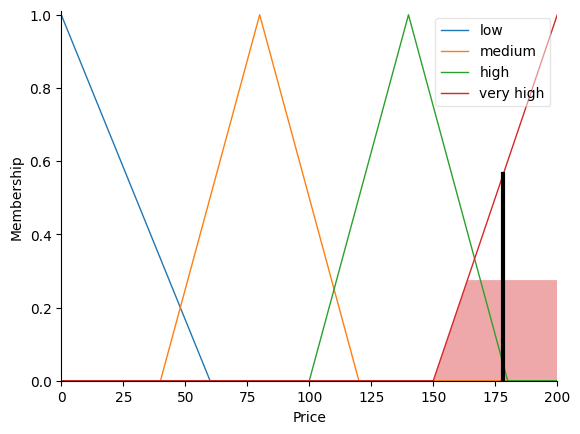

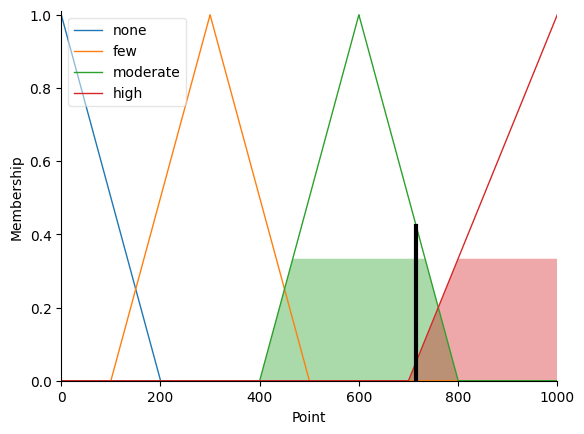

In [ ]:
import numpy as np #2.11 Bỏ
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import random
import matplotlib.pyplot as plt
Ride_distance = ctrl.Antecedent(np.arange(0, 50.1, 0.1), 'Ride_distance')
Traffic_condition = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Traffic_condition')
Demand_level = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Demand_level')
Weather_condition = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Weather_condition')
Rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Rating')
Ride_punctuality = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Ride_punctuality')
Price = ctrl.Consequent(np.arange(0, 200.1, 0.1), 'Price')
Point = ctrl.Consequent(np.arange(0, 1000.1, 0.1), "Point")

Ride_distance['short'] = fuzz.trimf(Ride_distance.universe, [0, 0, 5])
Ride_distance['medium'] = fuzz.trimf(Ride_distance.universe, [2, 10, 18])
Ride_distance['long'] = fuzz.trimf(Ride_distance.universe, [12, 25, 35])
Ride_distance['very long'] = fuzz.trimf(Ride_distance.universe, [25, 50, 50])

Traffic_condition['low'] = fuzz.trimf(Traffic_condition.universe, [0, 0, 40])
Traffic_condition['medium'] = fuzz.trimf(Traffic_condition.universe, [20, 50, 80])
Traffic_condition['high'] = fuzz.trimf(Traffic_condition.universe, [60, 100, 100])

Demand_level['low'] = fuzz.trimf(Demand_level.universe, [0, 0, 40])
Demand_level['medium'] = fuzz.trimf(Demand_level.universe, [20, 50, 80])
Demand_level['high'] = fuzz.trimf(Demand_level.universe, [60, 100, 100])

Weather_condition['good'] = fuzz.trimf(Weather_condition.universe, [0, 0, 40])
Weather_condition['medium'] = fuzz.trimf(Weather_condition.universe, [20, 50, 80])
Weather_condition['bad'] = fuzz.trimf(Weather_condition.universe, [60, 100, 100])

Rating['poor'] = fuzz.trimf(Rating.universe, [0, 0, 2.5])
Rating['average'] = fuzz.trimf(Rating.universe, [1.5, 3, 4.5])
Rating['good'] = fuzz.trimf(Rating.universe, [3.5, 5, 5])

Ride_punctuality['late'] = fuzz.trimf(Ride_punctuality.universe, [0, 0, 40])
Ride_punctuality['on time'] = fuzz.trimf(Ride_punctuality.universe, [30, 60, 90])
Ride_punctuality['early'] = fuzz.trimf(Ride_punctuality.universe, [70, 100, 100])

Price['low'] = fuzz.trimf(Price.universe, [0, 0, 60])
Price['medium'] = fuzz.trimf(Price.universe, [40, 80, 120])
Price['high'] = fuzz.trimf(Price.universe, [100, 140, 180])
Price['very high'] = fuzz.trimf(Price.universe, [150, 200, 200])

Point['none'] = fuzz.trimf(Point.universe, [0, 0, 200])
Point['few'] = fuzz.trimf(Point.universe, [100, 300, 500])
Point['moderate'] = fuzz.trimf(Point.universe, [400, 600, 800])
Point['high'] = fuzz.trimf(Point.universe, [700, 1000, 1000])

r1 = ctrl.Rule(Ride_distance['short'] & Traffic_condition['low'] & Demand_level['low'], Price['low'])
r2 = ctrl.Rule(Ride_distance['short'] & Traffic_condition['medium'] & Demand_level['high'], Price['medium'])
r3 = ctrl.Rule(Ride_distance['medium'] & Traffic_condition['high'] & Demand_level['high'], Price['high'])
r4 = ctrl.Rule(Ride_distance['long'] & Traffic_condition['medium'] & Weather_condition['good'], Price['medium'])
r5 = ctrl.Rule(Ride_distance['long'] & Traffic_condition['high'] & Weather_condition['bad'], Price['very high'])
r6 = ctrl.Rule(Ride_distance['long'] & Traffic_condition['high'] & Demand_level['high'], Price['very high'])
r7 = ctrl.Rule(Ride_distance['medium'] & Traffic_condition['low'] & Demand_level['low'], Price['medium'])
r8 = ctrl.Rule(Ride_distance['short'] & Traffic_condition['high'] & Weather_condition['bad'], Price['high'])
r9 = ctrl.Rule(Ride_distance['very long'] & Weather_condition['bad'], Price['very high'])
r10 = ctrl.Rule(Ride_distance['medium'] & Traffic_condition['medium'] & Weather_condition['medium'], Price['medium'])
r11 = ctrl.Rule(Rating['good'] & Ride_punctuality['early'], Point['high'])
r12 = ctrl.Rule(Rating['average'] & Ride_punctuality['early'], Point['moderate'])
r13 = ctrl.Rule(Rating['poor'] & Ride_punctuality['late'], Point['none'])
r14 = ctrl.Rule(Ride_distance['long'] & Traffic_condition['high'] & Ride_punctuality['on time'], Point['high'])
r15 = ctrl.Rule(Ride_distance['medium'] & Traffic_condition['medium'] & Rating['good'], Point['moderate'])
r17 = ctrl.Rule(Ride_distance['long'] & Weather_condition['bad'] & Rating['good'], Point['high'])
r18 = ctrl.Rule(Ride_distance['short'] & Ride_punctuality['on time'] & Rating['average'], Point['few'])
r19 = ctrl.Rule(Ride_distance['long'] & Ride_punctuality['late'] & Traffic_condition['high'], Point['few'])
r20 = ctrl.Rule(Ride_distance['medium'] & Weather_condition['medium'] & Rating['good'], Point['moderate'])

grab_ctrl = ctrl.ControlSystem([r1,r2,r3,r4,r5,r6,r7,r8,r9,r10,r11,r12,r13,r14,r15,r17,r18,r19,r20])
grab_sim = ctrl.ControlSystemSimulation(grab_ctrl)

try:
    grab_sim.input['Ride_distance'] = float(input('Ride_distance (0->50): '))
    grab_sim.input['Traffic_condition'] = float(input('Traffic_condition (0->100): '))
    grab_sim.input['Demand_level'] = float(input('Demand_level (0->100): '))

    a = input('Weather condition (xau, dep, trung binh): ')
    if a == 'xau':
        grab_sim.input['Weather_condition'] = float(random.randint(60,100))
    elif a == 'dep':
        grab_sim.input['Weather_condition'] = float(random.randint(0,40))
    elif a == 'trung binh':
        grab_sim.input['Weather_condition'] = float(random.randint(20,80))

    grab_sim.input['Rating'] = float(input('Rating (1->5): '))

    b = input('Ride_punctuality (on time, late, early): ')
    if b == 'late':
        grab_sim.input['Ride_punctuality'] = float(random.randint(0,40))
    elif b == 'early':
        grab_sim.input['Ride_punctuality'] = float(random.randint(70,100))
    elif b == 'on time':
        grab_sim.input['Ride_punctuality'] = float(random.randint(30,90))

    grab_sim.compute()
    print(f" Price (Giá cước): {grab_sim.output['Price']:.2f} nghìn đồng")
    print(f" Point (Điểm thưởng): {grab_sim.output['Point']:.2f} điểm")
    Price.view(sim=grab_sim)
    Point.view(sim=grab_sim)
    plt.show()
except:
  pass

Store rating (0 -> 5): 4.5
Sales volume (0 -> 100): 20
Profit margin (0 -> 100): 10
Seasonal event (0 -> 10): 0
Competitor discount (0 -> 100): 10
Mức chiết khấu đề xuất: 48.49 %


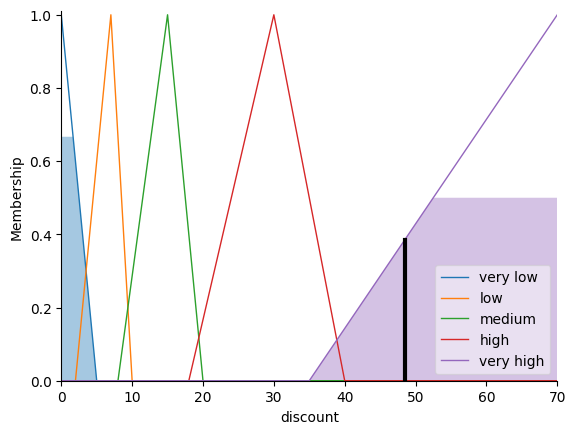

In [ ]:
import numpy as np #2.12
import skfuzzy as fuzz
from skfuzzy import control as ctrl
store_rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'store_rating')
sales_volume = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'sales_volume')
profit_margin = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'profit_margin')
seasonal_event = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'seasonal_event')
competitor_discount = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'competitor_discount')
discount = ctrl.Consequent(np.arange(0, 70.1, 0.1), 'discount')

store_rating['low'] = fuzz.trimf(store_rating.universe, [0, 0, 3])
store_rating['medium'] = fuzz.trimf(store_rating.universe, [2.5, 3.5, 4.5])
store_rating['high'] = fuzz.trimf(store_rating.universe, [4, 5, 5])

sales_volume['low'] = fuzz.trimf(sales_volume.universe, [0, 0, 40])
sales_volume['medium'] = fuzz.trimf(sales_volume.universe, [30, 50, 70])
sales_volume['high'] = fuzz.trimf(sales_volume.universe, [60, 100, 100])

profit_margin['low'] = fuzz.trimf(profit_margin.universe, [0, 0, 30])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe, [20, 50, 80])
profit_margin['high'] = fuzz.trimf(profit_margin.universe, [60, 100, 100])

seasonal_event['none'] = fuzz.trimf(seasonal_event.universe, [0, 0, 3])
seasonal_event['moderate'] = fuzz.trimf(seasonal_event.universe, [2, 5, 8])
seasonal_event['high'] = fuzz.trimf(seasonal_event.universe, [7, 10, 10])

competitor_discount['low'] = fuzz.trimf(competitor_discount.universe, [0, 0, 30])
competitor_discount['medium'] = fuzz.trimf(competitor_discount.universe, [20, 50, 80])
competitor_discount['high'] = fuzz.trimf(competitor_discount.universe, [60, 100, 100])

discount['very low'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['low'] = fuzz.trimf(discount.universe, [2, 7, 10])
discount['medium'] = fuzz.trimf(discount.universe, [8, 15, 20])
discount['high'] = fuzz.trimf(discount.universe, [18, 30, 40])
discount['very high'] = fuzz.trimf(discount.universe, [35, 70, 70])
#rule
r1 = ctrl.Rule(store_rating['high'] & sales_volume['high'] & profit_margin['high'], discount['very low'])
r2 = ctrl.Rule(store_rating['low'] & sales_volume['low'] & profit_margin['high'], discount['high'])
r3 = ctrl.Rule(seasonal_event['high'] & competitor_discount['high'], discount['very high'])
r4 = ctrl.Rule(store_rating['medium'] & sales_volume['medium'] & profit_margin['medium'], discount['medium'])
r5 = ctrl.Rule(competitor_discount['low'] & profit_margin['low'], discount['very low'])
r6 = ctrl.Rule(store_rating['low'] & seasonal_event['none'], discount['medium'])
r7 = ctrl.Rule(sales_volume['low'] & profit_margin['low'], discount['very high'])

shop_ctrl = ctrl.ControlSystem([r1, r2, r3, r4, r5, r6, r7])
shop_sim = ctrl.ControlSystemSimulation(shop_ctrl)
try:
    shop_sim.input['store_rating'] = float(input('Store rating (0 -> 5): '))
    shop_sim.input['sales_volume'] = float(input('Sales volume (0 -> 100): '))
    shop_sim.input['profit_margin'] = float(input('Profit margin (0 -> 100): '))
    shop_sim.input['seasonal_event'] = float(input('Seasonal event (0 -> 10): ')) # Đã sửa tên biến
    shop_sim.input['competitor_discount'] = float(input('Competitor discount (0 -> 100): ')) # Đã sửa tên biến

    shop_sim.compute()
    print(f"Mức chiết khấu đề xuất: {shop_sim.output['discount']:.2f} %")
    discount.view(sim=shop_sim)

except:
  pass

sản phẩm: Đồng hồ Rolex
product demand (0->100):50
competitor price pressure (0->100):60
uy tin (0->5):3
loi nhuan (0->100):80
seasonal demand (0->10):5
Mức chiết khấu đề xuất: 14.22 %


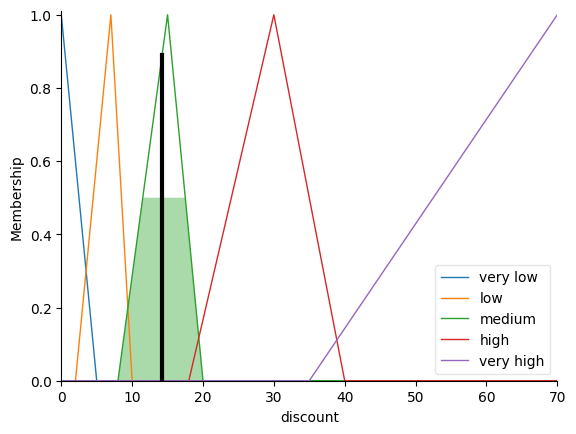

In [ ]:
#2.13
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
product_demand=ctrl.Antecedent(np.arange(0,100.1,0.1),'product_demand')
competitor_price=ctrl.Antecedent(np.arange(0,100.1,0.1),'competitor_price')
uy_tin=ctrl.Antecedent(np.arange(0,5.1,0.1),'uy_tin')
profit_margin=ctrl.Antecedent(np.arange(0,100.1,0.1),'profit_margin')
seasonal_demand=ctrl.Antecedent(np.arange(0,10.1,0.1),'seasonal_demand')
discount=ctrl.Consequent(np.arange(0,70.1,0.1),'discount')

product_demand['low']=fuzz.trimf(product_demand.universe,[0, 0, 30])
product_demand['medium']=fuzz.trimf(product_demand.universe,[20, 45, 70])
product_demand['high']=fuzz.trimf(product_demand.universe,[60, 100, 100])
#product_demand.view()
competitor_price['low']=fuzz.trimf(competitor_price.universe,[0, 0, 50])
competitor_price['medium']=fuzz.trimf(competitor_price.universe,[40, 60, 80])
competitor_price['high']=fuzz.trimf(competitor_price.universe,[70, 100, 100])
#competitor_price.view()
uy_tin['low']=fuzz.trimf(uy_tin.universe,[0, 0, 2.5])
uy_tin['medium']=fuzz.trimf(uy_tin.universe,[1.5, 3, 4.5])
uy_tin['high']=fuzz.trimf(uy_tin.universe,[3.5, 5, 5])
#uy_tin.view()
profit_margin['low'] = fuzz.trimf(profit_margin.universe, [0, 0, 30])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe, [20, 50, 80])
profit_margin['high'] = fuzz.trimf(profit_margin.universe, [60, 100, 100])
#profit_margin.view()
seasonal_demand['none'] = fuzz.trimf(seasonal_demand.universe, [0, 0, 3])
seasonal_demand['moderate'] = fuzz.trimf(seasonal_demand.universe, [2, 5, 8])
seasonal_demand['high'] = fuzz.trimf(seasonal_demand.universe, [7, 10, 10])
#seasonal_demand.view()
discount['very low'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['low'] = fuzz.trimf(discount.universe, [2, 7, 10])
discount['medium'] = fuzz.trimf(discount.universe, [8, 15, 20])
discount['high'] = fuzz.trimf(discount.universe, [18, 30, 40])
discount['very high'] = fuzz.trimf(discount.universe, [35, 70, 70])
#discount.view()
#rule
r1 = ctrl.Rule(product_demand['high'] & competitor_price['low'] & profit_margin['low'], discount['very low'])
r2 = ctrl.Rule(product_demand['low'] & competitor_price['high'] & profit_margin['high'], discount['high'] )
r3 = ctrl.Rule(uy_tin['high'] & profit_margin['medium'] & seasonal_demand['high'], discount['medium'])
r4 = ctrl.Rule(competitor_price['high'] & seasonal_demand['high'] & profit_margin['high'] , discount['high'])
r5 = ctrl.Rule(uy_tin['low'] & profit_margin['low'] & product_demand['medium'], discount['medium'])
r6 = ctrl.Rule(product_demand['high'] & seasonal_demand['none'] & competitor_price['low'] , discount['very low'])
r7 = ctrl.Rule(profit_margin['high'] & competitor_price['medium'] & seasonal_demand['moderate'], discount['medium'])

shop1_ctrl = ctrl.ControlSystem([r1,r2,r3,r4,r5,r6,r7])
shop1_sim= ctrl.ControlSystemSimulation(shop1_ctrl)
print('sản phẩm: Đồng hồ Rolex')
try:
  shop1_sim.input['product_demand']=float(input('product demand (0->100):'))
  shop1_sim.input['competitor_price']=float(input('competitor price pressure (0->100):'))
  shop1_sim.input['uy_tin']=float(input('uy tin (0->5):'))
  shop1_sim.input['profit_margin']=float(input('loi nhuan (0->100):'))
  shop1_sim.input['seasonal_demand']=float(input('seasonal demand (0->10):'))

  shop1_sim.compute()
  print(f"Mức chiết khấu đề xuất: {shop1_sim.output['discount']:.2f} %")
  discount.view(sim=shop1_sim)
     #50,60,3,80,5
except:
  pass

Mật độ đơn (0-10): 3
Độ khẩn cấp (0-10): 9.5
Tải tài xế (0-100): 60
Giao thông (0-100): 90
Lợi nhuận (0-100): 95
Số đơn kết hợp: 1.4 đơn
Mức ưu tiên giao hàng theo thang điểm 1-100: 86.3


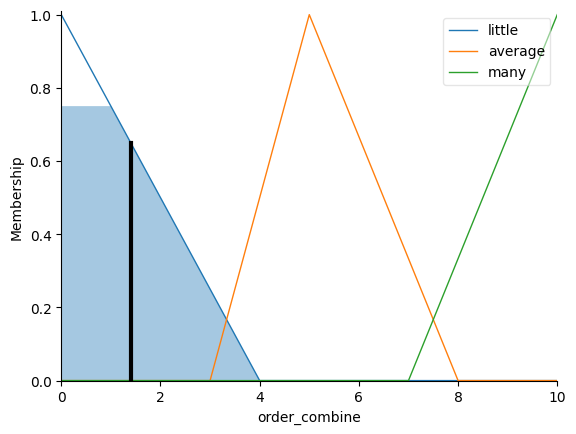

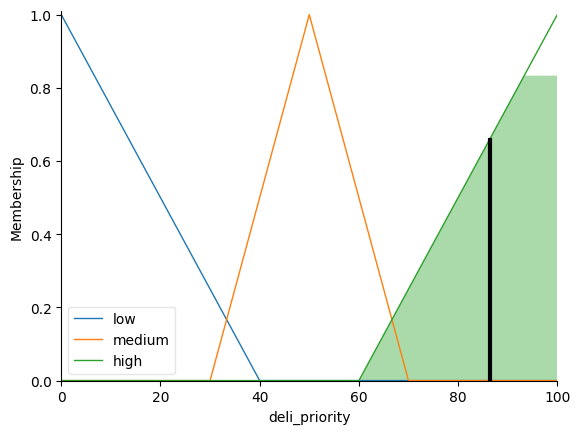

In [ ]:
#2.14
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
order_density = ctrl.Antecedent(np.arange(0, 11, 1), 'order_density')
delivery_urgent = ctrl.Antecedent(np.arange(0, 11, 1), 'delivery_urgent')
load = ctrl.Antecedent(np.arange(0, 101, 1), 'load')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
profit = ctrl.Antecedent(np.arange(0, 101, 1), 'profit')

order_combine = ctrl.Consequent(np.arange(0, 11, 1), 'order_combine')
deli_priority = ctrl.Consequent(np.arange(0, 101, 1), 'deli_priority')

order_density['low'] = fuzz.trimf(order_density.universe, [0, 0, 4])
order_density['medium'] = fuzz.trimf(order_density.universe, [3, 6, 8])
order_density['high'] = fuzz.trimf(order_density.universe, [7, 10, 10])

load['low'] = fuzz.trimf(load.universe, [0, 0, 40])
load['medium'] = fuzz.trimf(load.universe, [30, 50, 70])
load['high'] = fuzz.trimf(load.universe, [60, 100, 100])

delivery_urgent['low'] = fuzz.trimf(delivery_urgent.universe, [0, 0, 3])
delivery_urgent['medium'] = fuzz.trimf(delivery_urgent.universe, [2, 5, 8])
delivery_urgent['high'] = fuzz.trimf(delivery_urgent.universe, [7, 10, 10])

traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 30])
traffic['medium'] = fuzz.trimf(traffic.universe, [20, 45, 70])
traffic['high'] = fuzz.trimf(traffic.universe, [60, 100, 100])

profit['low'] = fuzz.trimf(profit.universe, [0, 0, 30])
profit['medium'] = fuzz.trimf(profit.universe, [20, 50, 80])
profit['high'] = fuzz.trimf(profit.universe, [60, 100, 100])

order_combine['little'] = fuzz.trimf(order_combine.universe, [0, 0, 4])
order_combine['average'] = fuzz.trimf(order_combine.universe, [3, 5, 8])
order_combine['many'] = fuzz.trimf(order_combine.universe, [7, 10, 10])

deli_priority['low'] = fuzz.trimf(deli_priority.universe, [0, 0, 40])
deli_priority['medium'] = fuzz.trimf(deli_priority.universe, [30, 50, 70])
deli_priority['high'] = fuzz.trimf(deli_priority.universe, [60, 100, 100])
#rule
#rule order combine
r1 = ctrl.Rule(order_density['high'] & load['low'] & traffic['low'], order_combine['many'])
r2 = ctrl.Rule(order_density['medium'] & traffic['high'] & delivery_urgent['medium'], order_combine['little'])
r3 = ctrl.Rule(load['high'] & order_density['high'] & profit['medium'], order_combine['average'])
r4 = ctrl.Rule(order_density['low'] & delivery_urgent['high'] & traffic['medium'], order_combine['little'])
r5 = ctrl.Rule(profit['high'] & delivery_urgent['high'] & traffic['high'], order_combine['little'])
#rule deli priority
r6 = ctrl.Rule(delivery_urgent['high'] & profit['high'], deli_priority['high'])
r7 = ctrl.Rule(delivery_urgent['medium'] & traffic['medium'], deli_priority['medium'])
r8 = ctrl.Rule(delivery_urgent['low'] & order_density['high'] & profit['low'], deli_priority['low'])

delivery_ctrl = ctrl.ControlSystem([r1, r2, r3, r4, r5, r6, r7, r8])
delivery_sim = ctrl.ControlSystemSimulation(delivery_ctrl)
try:
    delivery_sim.input['order_density'] = float(input('Mật độ đơn (0-10): '))
    delivery_sim.input['delivery_urgent'] = float(input('Độ khẩn cấp (0-10): '))
    delivery_sim.input['load'] = float(input('Tải tài xế (0-100): '))
    delivery_sim.input['traffic'] = float(input('Giao thông (0-100): '))
    delivery_sim.input['profit'] = float(input('Lợi nhuận (0-100): '))

    delivery_sim.compute()
    print(f"Số đơn kết hợp: {delivery_sim.output['order_combine']:.1f} đơn")
    order_combine.view(sim=delivery_sim)
    print(f"Mức ưu tiên giao hàng theo thang điểm 1-100: {delivery_sim.output['deli_priority']:.1f}")
    deli_priority.view(sim=delivery_sim)
     #3,9.5,60,90,95
except:
  pass